In [73]:
## code for matrix inversion using gauss jordan elimination method
import time
import copy
def invSolve(A1):
    A=copy.deepcopy(A1)
    ## same assumptions as before, since we are not allowed to use an in-built packages, we just assume a matrix is a list of lists, since we must perform inversion, this solution only holds for nxn matrices
    ## we inverse using the adjoint matrix method or gauss jordan elimination method
    n=len(A)
    I = [[0]*n for _ in range(n)]
    for i in range(n):
        I[i][i]=1
    ## We thus have our identity matrix to adjoint matrix ready
    for i in range(n):
        ## we know any row/column in excess of the rank automatically becomes zero in our process of GE as they are not independent and hence expressible as a linear combination of the independent row so they take care of themselves by becoming zero and being swapped out to the very end of the rows
        ## we have so far ensure that the first element of first row in the original system is no longer a zero, we will now proceed with the process of elimination and keep our strategy of partial pivoting everytime
        # normalize row i
        # pivoting
        if A[i][i] == 0:
            t = i + 1
            while t<n and A[t][i]==0:
                t+=1
            if t==n:
                raise ValueError("Matrix is singular")
            A[i],A[t]= A[t],A[i]
            I[i],I[t]=I[t],I[i]
        # normalize pivot row
        pivot=A[i][i]
        for k in range(n):
            A[i][k]/=pivot
            I[i][k]/=pivot
        for j in range(i+1,n): ## row loop
            multiple=A[j][i]/A[i][i]
            for k in range(0,n): ## column loop
                A[j][k]=A[j][k]-multiple*A[i][k]
                I[j][k]=I[j][k]-multiple*I[i][k]
        ## we are done with forward elimination, now we perform backward elimination
    for i in range(n-1, -1, -1):
         for j in range(i-1, -1, -1):
             ## we just eliminate the trailing zeroes
          multiple = A[j][i]
          for k in range(n):
            A[j][k]-=multiple*A[i][k]
            I[j][k]-=multiple*I[i][k]
    return I

In [74]:
## code for inversion using inbuilt functions
import numpy as np
def invSolve2(A):
    A=np.array(A)
    I=np.linalg.inv(A)
    return I

In [75]:
A2 = [
    [2, 1],
    [5, 3]
]
A4 = [
    [1, 2, 3, 4],
    [2, 5, 2, 1],
    [3, 1, 6, 2],
    [4, 2, 1, 7]
]
A8 = [
    [10, 2, 3, 4, 5, 6, 7, 8],
    [1, 11, 2, 3, 4, 5, 6, 7],
    [2, 1, 12, 2, 3, 4, 5, 6],
    [3, 2, 1, 13, 2, 3, 4, 5],
    [4, 3, 2, 1, 14, 2, 3, 4],
    [5, 4, 3, 2, 1, 15, 2, 3],
    [6, 5, 4, 3, 2, 1, 16, 2],
    [7, 6, 5, 4, 3, 2, 1, 17]
]
A16 = [
    [20 if i==j else (1 if j>i else 2) for j in range(16)]
    for i in range(16)
]

In [76]:
invSolve(A2)

[[3.0, -1.0], [-5.0, 2.0]]

In [77]:
invSolve2(A2)

array([[ 3., -1.],
       [-5.,  2.]])

In [78]:
invSolve(A4)

[[-0.4552238805970148,
  0.06716417910447758,
  0.17164179104477623,
  0.20149253731343283],
 [0.08208955223880587,
  0.2064676616915423,
  -0.10199004975124382,
  -0.04726368159203981],
 [0.1417910447761196,
  -0.03731343283582089,
  0.12686567164179102,
  -0.11194029850746268],
 [0.21641791044776107,
  -0.09203980099502487,
  -0.08706467661691542,
  0.0572139303482587]]

In [79]:
invSolve2(A4)

array([[-0.45522388,  0.06716418,  0.17164179,  0.20149254],
       [ 0.08208955,  0.20646766, -0.10199005, -0.04726368],
       [ 0.14179104, -0.03731343,  0.12686567, -0.1119403 ],
       [ 0.21641791, -0.0920398 , -0.08706468,  0.05721393]])

In [80]:
invSolve(A8)

[[-1.7895210543555655,
  -1.2016178552074173,
  -0.47708747997840284,
  0.15364165173290098,
  0.6272657335442252,
  0.9225295678540547,
  1.047115237249034,
  1.026525172368543],
 [-1.6461554026507128,
  -0.9304465504754587,
  -0.4052571529314419,
  0.13800502255340835,
  0.5451388714981608,
  0.7981607677875416,
  0.9039709625492203,
  0.8847592449942248],
 [-1.1256129188007167,
  -0.6965732642690496,
  -0.1753646459921244,
  0.09869808283506806,
  0.37136192936570955,
  0.5399780826747947,
  0.609481446904077,
  0.5950158119277125],
 [-0.4608468221381008,
  -0.2827605412016662,
  -0.10206907363239588,
  0.1295503742874114,
  0.15017274418334411,
  0.21331427420897772,
  0.23795248307868272,
  0.23024836296212436],
 [0.22368293203325243,
  0.1427220556607902,
  0.05821438910464516,
  -0.015747568108488742,
  -0.00018231047473840634,
  -0.12103912963777305,
  -0.141605404003017,
  -0.14188287653874543],
 [0.8273629991876157,
  0.5174241733672439,
  0.19873269177409109,
  -0.0769888620

In [81]:
invSolve2(A8)

array([[-1.78952105e+00, -1.20161786e+00, -4.77087480e-01,
         1.53641652e-01,  6.27265734e-01,  9.22529568e-01,
         1.04711524e+00,  1.02652517e+00],
       [-1.64615540e+00, -9.30446550e-01, -4.05257153e-01,
         1.38005023e-01,  5.45138871e-01,  7.98160768e-01,
         9.03970963e-01,  8.84759245e-01],
       [-1.12561292e+00, -6.96573264e-01, -1.75364646e-01,
         9.86980828e-02,  3.71361929e-01,  5.39978083e-01,
         6.09481447e-01,  5.95015812e-01],
       [-4.60846822e-01, -2.82760541e-01, -1.02069074e-01,
         1.29550374e-01,  1.50172744e-01,  2.13314274e-01,
         2.37952483e-01,  2.30248363e-01],
       [ 2.23682932e-01,  1.42722056e-01,  5.82143891e-02,
        -1.57475681e-02, -1.82310475e-04, -1.21039130e-01,
        -1.41605404e-01, -1.41882877e-01],
       [ 8.27362999e-01,  5.17424173e-01,  1.98732692e-01,
        -7.69888620e-02, -2.82628817e-01, -3.42790272e-01,
        -4.73822670e-01, -4.67164331e-01],
       [ 1.28048266e+00,  7.981562

In [82]:
invSolve(A16)

[[0.051851928985838354,
  -0.0008229638482817304,
  -0.00086868406207516,
  -0.0009169442877460021,
  -0.0009678856370652243,
  -0.0010216570613466255,
  -0.001078415786976994,
  -0.0011383277751423825,
  -0.0012015682070947368,
  -0.0012683219963777774,
  -0.0013387843295098766,
  -0.0014131612367048695,
  -0.001491670194299585,
  -0.0015745407606495621,
  -0.0016620152473523155,
  -0.0017543494277607772],
 [-0.003508698855521554,
  0.05185192898583836,
  -0.0008229638482817301,
  -0.0008686840620751593,
  -0.0009169442877460017,
  -0.0009678856370652243,
  -0.0010216570613466253,
  -0.0010784157869769932,
  -0.0011383277751423819,
  -0.0012015682070947364,
  -0.0012683219963777771,
  -0.0013387843295098757,
  -0.001413161236704869,
  -0.001491670194299584,
  -0.0015745407606495604,
  -0.0016620152473523144],
 [-0.00332403049470463,
  -0.003508698855521554,
  0.05185192898583837,
  -0.0008229638482817299,
  -0.0008686840620751593,
  -0.0009169442877460018,
  -0.000967885637065224,
  -

In [83]:
invSolve2(A16)

array([[ 0.05185193, -0.00082296, -0.00086868, -0.00091694, -0.00096789,
        -0.00102166, -0.00107842, -0.00113833, -0.00120157, -0.00126832,
        -0.00133878, -0.00141316, -0.00149167, -0.00157454, -0.00166202,
        -0.00175435],
       [-0.0035087 ,  0.05185193, -0.00082296, -0.00086868, -0.00091694,
        -0.00096789, -0.00102166, -0.00107842, -0.00113833, -0.00120157,
        -0.00126832, -0.00133878, -0.00141316, -0.00149167, -0.00157454,
        -0.00166202],
       [-0.00332403, -0.0035087 ,  0.05185193, -0.00082296, -0.00086868,
        -0.00091694, -0.00096789, -0.00102166, -0.00107842, -0.00113833,
        -0.00120157, -0.00126832, -0.00133878, -0.00141316, -0.00149167,
        -0.00157454],
       [-0.00314908, -0.00332403, -0.0035087 ,  0.05185193, -0.00082296,
        -0.00086868, -0.00091694, -0.00096789, -0.00102166, -0.00107842,
        -0.00113833, -0.00120157, -0.00126832, -0.00133878, -0.00141316,
        -0.00149167],
       [-0.00298334, -0.00314908, -0

### Time for matrices of sizes 4x4,8x8 and 16x16

In [84]:
import timeit

setup = """
from __main__ import invSolve
A = [[4.0, 7.0], [2.0, 6.0]]
"""

stmt = "invSolve([row[:] for row in A])"

print(timeit.timeit(stmt, setup=setup, number=100))


0.000880700012203306


In [85]:
import timeit

setup = """
from __main__ import invSolve2
A = [[4.0, 7.0], [2.0, 6.0]]
"""

stmt = "invSolve2([row[:] for row in A])"

print(timeit.timeit(stmt, setup=setup, number=100))


0.0009673000313341618


In [86]:
import timeit

setup = """
from __main__ import invSolve
A4 = [
    [1, 2, 3, 4],
    [2, 5, 2, 1],
    [3, 1, 6, 2],
    [4, 2, 1, 7]
]
"""

stmt = "invSolve([row[:] for row in A4])"

print(timeit.timeit(stmt, setup=setup, number=100))

0.0032059000222943723


In [87]:
import timeit

setup = """
from __main__ import invSolve2
A4 = [
    [1, 2, 3, 4],
    [2, 5, 2, 1],
    [3, 1, 6, 2],
    [4, 2, 1, 7]
]
"""

stmt = "invSolve2([row[:] for row in A4])"

print(timeit.timeit(stmt, setup=setup, number=100))


0.0012946000206284225


In [88]:
import timeit

setup = """
from __main__ import invSolve
A8 = [
    [10, 2, 3, 4, 5, 6, 7, 8],
    [1, 11, 2, 3, 4, 5, 6, 7],
    [2, 1, 12, 2, 3, 4, 5, 6],
    [3, 2, 1, 13, 2, 3, 4, 5],
    [4, 3, 2, 1, 14, 2, 3, 4],
    [5, 4, 3, 2, 1, 15, 2, 3],
    [6, 5, 4, 3, 2, 1, 16, 2],
    [7, 6, 5, 4, 3, 2, 1, 17]
]
"""

stmt = "invSolve([row[:] for row in A8])"

print(timeit.timeit(stmt, setup=setup, number=100))

0.007968599966261536


In [89]:
import timeit

setup = """
from __main__ import invSolve2
A8 = [
    [10, 2, 3, 4, 5, 6, 7, 8],
    [1, 11, 2, 3, 4, 5, 6, 7],
    [2, 1, 12, 2, 3, 4, 5, 6],
    [3, 2, 1, 13, 2, 3, 4, 5],
    [4, 3, 2, 1, 14, 2, 3, 4],
    [5, 4, 3, 2, 1, 15, 2, 3],
    [6, 5, 4, 3, 2, 1, 16, 2],
    [7, 6, 5, 4, 3, 2, 1, 17]
]
"""

stmt = "invSolve2([row[:] for row in A8])"

print(timeit.timeit(stmt, setup=setup, number=100))


0.0018680000212043524


In [90]:
import timeit

setup = """
from __main__ import invSolve
A16 = [
    [20 if i==j else (1 if j>i else 2) for j in range(16)]
    for i in range(16)
]
"""

stmt = "invSolve([row[:] for row in A16])"

print(timeit.timeit(stmt, setup=setup, number=100))

0.045816500030923635


In [91]:
import timeit

setup = """
from __main__ import invSolve2
A16 = [
    [20 if i==j else (1 if j>i else 2) for j in range(16)]
    for i in range(16)
]
"""

stmt = "invSolve2([row[:] for row in A16])"

print(timeit.timeit(stmt, setup=setup, number=100))


0.00196599995251745


n=2, avg_time=0.000006
n=4, avg_time=0.000019
n=8, avg_time=0.000080
n=12, avg_time=0.000208
n=16, avg_time=0.000468
n=20, avg_time=0.000868
n=24, avg_time=0.001530
n=28, avg_time=0.002427
n=32, avg_time=0.003352
n=36, avg_time=0.004793
n=40, avg_time=0.006826


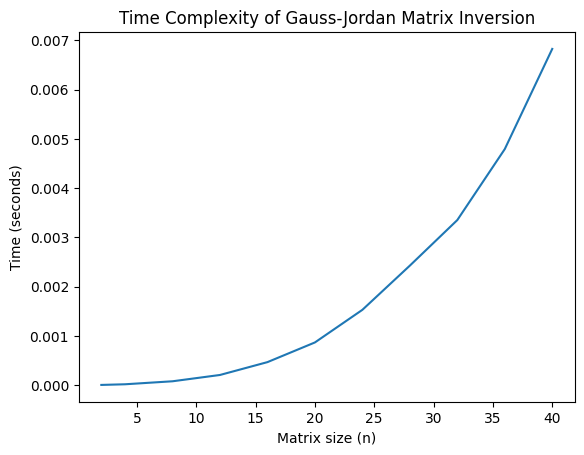

In [92]:
import time
import random
import matplotlib.pyplot as plt

# Generate random nxn matrix
def random_matrix(n):
    return [[random.random() for _ in range(n)] for _ in range(n)]

sizes = [2, 4, 8, 12, 16, 20, 24, 28, 32,36,40]  # you can increase gradually
times = []

for n in sizes:
    A = random_matrix(n)
    
    runs = 100   # repeat to reduce noise
    total_time = 0
    
    for _ in range(runs):
        start = time.perf_counter()
        invSolve(A)
        end = time.perf_counter()
        total_time += (end - start)
    
    avg_time = total_time / runs
    times.append(avg_time)
    print(f"n={n}, avg_time={avg_time:.6f}")

# Plot
plt.figure()
plt.plot(sizes, times)
plt.xlabel("Matrix size (n)")
plt.ylabel("Time (seconds)")
plt.title("Time Complexity of Gauss-Jordan Matrix Inversion")
plt.show()


n=2, avg_time=0.000006
n=4, avg_time=0.000006
n=8, avg_time=0.000010
n=12, avg_time=0.000013
n=16, avg_time=0.000017
n=20, avg_time=0.000023
n=24, avg_time=0.000033
n=28, avg_time=0.000044
n=32, avg_time=0.000057
n=36, avg_time=0.000060
n=40, avg_time=0.000072


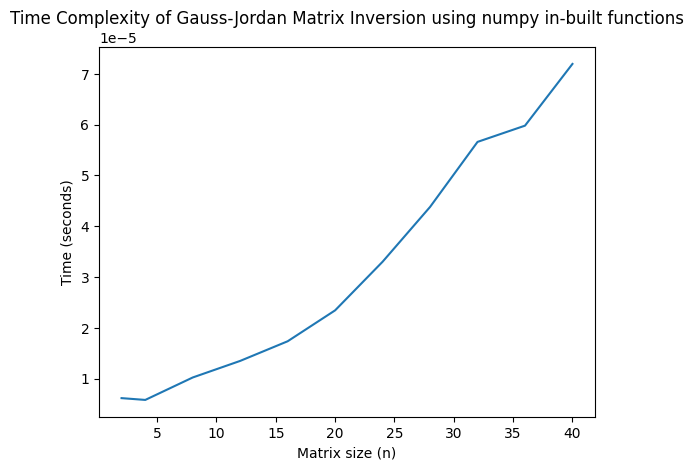

In [93]:
import time
import random
import matplotlib.pyplot as plt

# Generate random nxn matrix
def random_matrix(n):
    return [[random.random() for _ in range(n)] for _ in range(n)]

sizes = [2, 4, 8, 12, 16, 20, 24, 28, 32, 36, 40]  # you can increase gradually
times = []

for n in sizes:
    A = random_matrix(n)
    
    runs = 1000  # repeat to reduce noise
    total_time = 0
    
    for _ in range(runs):
        start = time.perf_counter()
        invSolve2(A)
        end = time.perf_counter()
        total_time += (end - start)
    
    avg_time = total_time / runs
    times.append(avg_time)
    print(f"n={n}, avg_time={avg_time:.6f}")

# Plot
plt.figure()
plt.plot(sizes, times)
plt.xlabel("Matrix size (n)")
plt.ylabel("Time (seconds)")
plt.title("Time Complexity of Gauss-Jordan Matrix Inversion using numpy in-built functions")
plt.show()


n=2 | custom=0.000008 | numpy=0.000008
n=4 | custom=0.000023 | numpy=0.000008
n=8 | custom=0.000113 | numpy=0.000020
n=12 | custom=0.000463 | numpy=0.000040
n=16 | custom=0.000477 | numpy=0.000017
n=20 | custom=0.000918 | numpy=0.000024
n=24 | custom=0.001508 | numpy=0.000042
n=28 | custom=0.002271 | numpy=0.000052
n=32 | custom=0.003644 | numpy=0.000076
n=36 | custom=0.004835 | numpy=0.000077
n=40 | custom=0.006479 | numpy=0.000095
n=44 | custom=0.008532 | numpy=0.000107
n=48 | custom=0.011256 | numpy=0.000117
n=52 | custom=0.014241 | numpy=0.000139
n=56 | custom=0.017830 | numpy=0.000146
n=60 | custom=0.023715 | numpy=0.000177


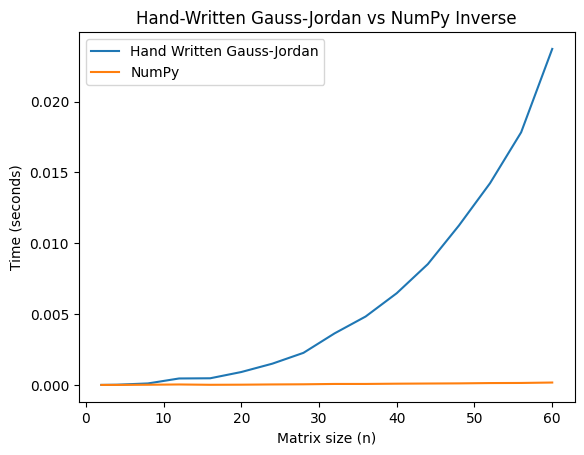

In [94]:
import time
import random
import numpy as np
import matplotlib.pyplot as plt

# Your functions assumed defined:
# invSolve(A)
# invSolve2(A)

def random_matrix(n):
    return [[random.random() for _ in range(n)] for _ in range(n)]

sizes = [2, 4, 8, 12, 16, 20, 24, 28, 32,36,40,44,48,52,56,60] 

times_custom = []
times_numpy = []

for n in sizes:
    runs = 100
    total_custom = 0
    total_numpy = 0

    for _ in range(runs):
        A = random_matrix(n)

        # ---- Custom inverse ----
        start = time.perf_counter()
        invSolve(A)
        end = time.perf_counter()
        total_custom += (end - start)

        # ---- NumPy inverse ----
        A_np = np.array(A)
        start = time.perf_counter()
        invSolve2(A_np)
        end = time.perf_counter()
        total_numpy += (end - start)

    times_custom.append(total_custom / runs)
    times_numpy.append(total_numpy / runs)

    print(f"n={n} | custom={times_custom[-1]:.6f} | numpy={times_numpy[-1]:.6f}")

# ---- Plot both on same graph ----
plt.figure()
plt.plot(sizes, times_custom)
plt.plot(sizes, times_numpy)
plt.xlabel("Matrix size (n)")
plt.ylabel("Time (seconds)")
plt.title("Hand-Written Gauss-Jordan vs NumPy Inverse")
plt.legend(["Hand Written Gauss-Jordan", "NumPy"])
plt.show()
